## Getting ready to use Kaggle datasets.

In [2]:
!pip install kaggle

In [3]:
# This is to perform grad-cam based visualization
# Takes around 1.5 minutes
!pip install grad-cam

In [4]:
# Create a hidden directory named '.kaggle' in the home folder
!mkdir ~/.kaggle

mkdir: cannot create directory ‘/root/.kaggle’: File exists


In [5]:
# Copy the Kaggle API key to the .kaggle directory
!cp kaggle.json ~/.kaggle/

# Set the file permissions to read and write only for the user
!chmod 600 ~/.kaggle/kaggle.json

Download the dataset!

In [6]:
# Download the dataset from Kaggle
!kaggle datasets download gpiosenka/butterfly-images40-species

Dataset URL: https://www.kaggle.com/datasets/gpiosenka/butterfly-images40-species
License(s): CC0-1.0
butterfly-images40-species.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
# unzip the data quietly
!unzip -q butterfly-images40-species.zip

##Getting ready for coding our DL model

In [7]:
import numpy as np
import torch
import torchvision
import torch.nn as nn
import os
from torchvision.transforms import transforms

import warnings
warnings.filterwarnings('ignore')
from torchvision import models
import numpy as np
import cv2

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image, \
    deprocess_image, \
    preprocess_image
from PIL import Image
import matplotlib.pyplot as plt

# Select device

In [8]:
# Check if GPU is available, otherwise use CPU
device = "cuda" if torch.cuda.is_available() else "cpu"

# Print the selected device
print(device)

cuda


In [9]:
# Get the number of classes by counting the subdirectories in the training dataset
num_classes = len(os.listdir("/content/train"))

# Print the number of classes in the dataset
print("There are ", num_classes, " classes in the dataset")

There are  100  classes in the dataset


In [10]:
# Define normalization using mean and standard deviation values (pretrained model values like ImageNet)
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

# Define transformation pipeline for training dataset
train_transform = transforms.Compose([
    transforms.Resize((150, 150)),         # Resize the image to 150x150 pixels
    transforms.ToTensor(),                 # Convert the image to a tensor and scale values to [0,1]
    normalize,                             # Normalize using predefined mean and std values
    transforms.RandomHorizontalFlip()      # Apply random horizontal flip with a 50% probability
])

# Define transformation pipeline for testing dataset
test_transform = transforms.Compose([
    transforms.Resize((150, 150)),         # Resize the image to 150x150 pixels
    transforms.ToTensor(),                 # Convert the image to a tensor and scale values to [0,1]
    normalize                              # Normalize using predefined mean and std values
])

In [11]:

# Load training dataset from the specified directory and apply transformations
train_images_path = torchvision.datasets.ImageFolder(
    "/content/train",         # Path to the training dataset
    transform=train_transform # Apply the defined train_transform pipeline
)

# Load testing dataset from the specified directory and apply transformations
test_images_path = torchvision.datasets.ImageFolder(
    "/content/test",         # Path to the testing dataset
    transform=test_transform # Apply the defined test_transform pipeline
)

# Print the number of images in the training and testing datasets
len(train_images_path), len(test_images_path)


(12594, 500)

In [12]:
# Create a DataLoader for the training dataset
train_loader = torch.utils.data.DataLoader(
    dataset=train_images_path,  # Use the training dataset created earlier
    batch_size=256,             # Load images in batches of 256
    num_workers=4,              # Use 4 subprocesses to load data in parallel (speeds up loading)
    shuffle=True                # Shuffle the data at every epoch to improve training generalization
)

# Create a DataLoader for the testing dataset
test_loader = torch.utils.data.DataLoader(
    dataset=test_images_path,  # Use the testing dataset created earlier
    batch_size=256,            # Load images in batches of 256
    num_workers=4,             # Use 4 subprocesses to load data in parallel
    shuffle=True               # Shuffle the test data (not strictly necessary for evaluation but can help)
)

In [13]:
# Print the total number of training images
print("Train Image: ", len(train_images_path))

# Print the total number of testing images
print("Test Image: ", len(test_images_path))

# Print the total number of batches in the training DataLoader
# This is calculated as total images / batch size (rounded up if needed)
print("Train len batch: ", len(train_loader))

# Print the total number of batches in the testing DataLoader
print("Test len batch: ", len(test_loader))


Train Image:  12594
Test Image:  500
Train len batch:  50
Test len batch:  2


# Create Model

Create a model frorm `torchvision.models`. We will use the popular `ResNet50` architecture.

In [14]:
# Load a pre-trained ResNet-50 model
model = torchvision.models.resnet50(pretrained=True).to(device)

# Print the model architecture
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [15]:
# Freeze all model parameters to prevent updates during training
for param in model.parameters():
    param.requires_grad = False  # This ensures pre-trained layers are not updated

# Get the number of input features of the last fully connected (FC) layer
lastLayer = model.fc.in_features  # This is 2048 for ResNet-50

# Replace the final fully connected layer with a custom classifier
model.fc = nn.Sequential(
    nn.Linear(2048, 256),   # First fully connected layer (2048 → 256)
    nn.ReLU(inplace=True),  # Activation function (ReLU)
    nn.Linear(256, 100)     # Final output layer (256 → 100, assuming 100 classes)
).to(device)  # Move the new classifier to the same device as the model

# Print the updated model architecture
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [16]:
# Define the number of epochs (iterations over the entire dataset)
epochs = 3

# Define the optimizer (Adam) for training only the modified fully connected (fc) layer
optimizer = torch.optim.Adam(
    model.fc.parameters(),  # Optimize only the new classification layer
    lr=0.003  # Learning rate set to 0.003
)

# Define the loss function (CrossEntropyLoss for multi-class classification)
criterion = nn.CrossEntropyLoss()

# Define a learning rate scheduler to adjust the learning rate dynamically
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,     # Link the scheduler to the optimizer
    factor=0.001,  # Reduce LR by multiplying it by 0.001 when triggered
    patience=5,    # Wait for 5 epochs of no improvement before reducing LR
    verbose=True   # Print messages when LR is reduced
)

In [18]:

# Set an upper bound for tracking the best loss
upper = np.inf

# Lists to store loss and accuracy for visualization
train_loss_graph = []  # Stores training loss per epoch
test_loss_graph = []   # Stores testing loss per epoch
acc_graph = []         # Stores accuracy per epoch

# Loop through multiple training epochs
for epoch in range(epochs):
    model.train()  # Set the model to training mode

    train_loss = 0  # Initialize training loss for this epoch
    test_loss = 0   # Initialize testing loss for this epoch
    acc = 0         # Initialize accuracy for this epoch

    # Iterate over batches in the training data
    for img, label in train_loader:

        # Move images and labels to the specified device (CPU/GPU)
        img, label = img.to(device), label.to(device)

        # Forward pass: Get model predictions
        output = model(img)

        # Compute loss
        loss = criterion(output, label)

        # Zero the parameter gradients before backpropagation
        optimizer.zero_grad()

        # Backward pass: Compute gradients
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Accumulate total loss (multiply by batch size for correct averaging)
        train_loss += loss.item() * img.size(0)

    # Compute and store average training loss for this epoch
    train_loss_graph.append(train_loss / len(train_images_path))

    model.eval()  # Set the model to evaluation mode (disables dropout & batchnorm updates)

    # Loop through batches in the test dataset
    for test_img, test_label in test_loader:

        # Move test images and labels to the specified device (CPU/GPU)
        test_img, test_label = test_img.to(device), test_label.to(device)

        # Forward pass: Get model predictions
        test_output = model(test_img)

        # Compute loss for the batch
        test_loss_counter = criterion(test_output, test_label)

        # Accumulate total loss (multiply by batch size for correct averaging)
        test_loss += test_loss_counter.item() * test_img.size(0)

        # Get the predicted class with the highest probability
        _, pred = torch.max(test_output, 1)

        # Count number of correct predictions in the batch
        correct = torch.sum(pred == test_label.data)

        # Accumulate correct predictions for accuracy calculation
        acc += correct.item()  # Convert to Python int for numerical stability


    # Compute and store accuracy for this epoch
    acc_graph.append(acc / len(test_images_path))

    # Compute and store average test loss for this epoch
    test_loss_graph.append(test_loss / len(test_images_path))

    # Store the test loss value for learning rate scheduling
    test_upper = test_loss / len(test_images_path)

    # Adjust the learning rate if the test loss does not improve
    scheduler.step(test_upper)


    # Check if the current test loss is the best we've seen so far
    if test_upper < upper:
        upper = test_upper  # Update the "upper" bound with the new best test loss
        print("*" * 10, "Best performing model obtained", "*" * 10)  # Print a separator

        # Print information about the current epoch's losses and accuracy
        print("Epoch: ", epoch, "Train loss: ", train_loss / len(train_images_path),
            "Test loss: ", test_loss / len(test_images_path), "Accuracy: ", acc / len(test_images_path))

        print("Saving the best performing model!!")

        # Save the model's state_dict (weights) if it's the best performing so far
        torch.save(model.state_dict(), 'customResNet.pt')
    else:
        # If not the best model, still print epoch details but don't save the model
        print("Epoch: ", epoch, "Train loss: ", train_loss / len(train_images_path),
            "Test loss: ", test_loss / len(test_images_path), "Accuracy: ", acc / len(test_images_path))


********** Best performing model obtained **********
Epoch:  0 Train loss:  0.6553301715900051 Test loss:  0.5248310790061951 Accuracy:  0.844
Saving the best performing model!!
********** Best performing model obtained **********
Epoch:  1 Train loss:  0.48109051313535817 Test loss:  0.3900019674301147 Accuracy:  0.888
Saving the best performing model!!
********** Best performing model obtained **********
Epoch:  2 Train loss:  0.3902289658874789 Test loss:  0.35997773456573484 Accuracy:  0.896
Saving the best performing model!!


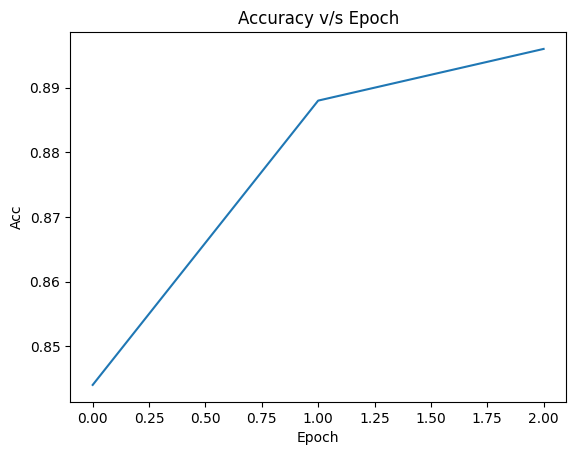

In [19]:
# Plot the accuracy graph (acc_graph stores accuracy values per epoch)
plt.plot(acc_graph)

# Label the x-axis as "Epoch"
plt.xlabel("Epoch")

# Label the y-axis as "Accuracy"
plt.ylabel("Acc")

# Add a title to the plot
plt.title("Accuracy v/s Epoch")

# Show the plot
plt.show()


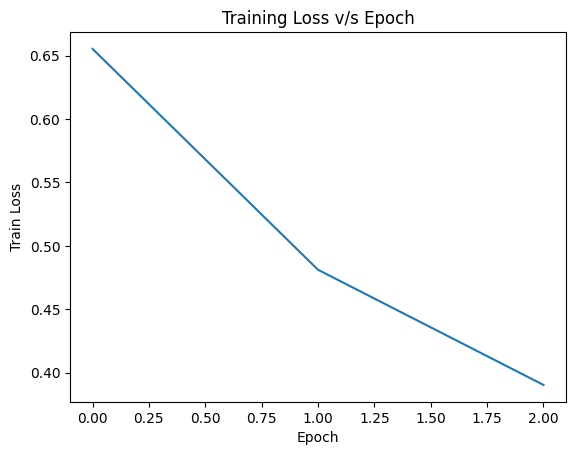

In [20]:
# Plot the training loss graph (train_loss_graph stores loss values per epoch)
plt.plot(train_loss_graph)

# Label the x-axis as "Epoch"
plt.xlabel("Epoch")

# Label the y-axis as "Train Loss"
plt.ylabel("Train Loss")

# Add a title to the plot
plt.title("Training Loss v/s Epoch")

# Show the plot
plt.show()


# Load Saved Model

In [21]:
# Load a fresh ResNet-50 model without pretrained weights
load_model = models.resnet50(pretrained=False)

# Get the number of input features to the final fully connected layer (fc)
lastLayer = load_model.fc.in_features  # For ResNet-50, this should be 2048

# Modify the fully connected layer for your specific task (100 classes)
load_model.fc = nn.Sequential(
    nn.Linear(lastLayer, 256),  # First layer: 2048 → 256
    nn.ReLU(inplace=True),  # ReLU activation
    nn.Linear(256, 100)  # Second layer: 256 → 100 (number of classes)
)

# Load the trained model's weights into the modified model
load_model.load_state_dict(torch.load("customResNet.pt"))

<All keys matched successfully>

## GradCAM Visualization


In [ ]:
l = sorted(os.listdir("valid"))
l.index("JULIA")

55

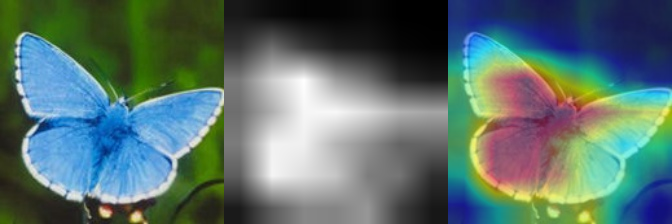

In [22]:
# Load a ResNet-50 model with pre-trained weights
model = models.resnet50(pretrained=True)

# Modify the fully connected (fc) layer for your specific task (100 classes)
model.fc = nn.Sequential(
    nn.Linear(2048, 256),  # First layer: 2048 → 256
    nn.ReLU(inplace=True),  # ReLU activation
    nn.Linear(256, 100)  # Second layer: 256 → 100 (number of classes)
)

# Load the trained model's weights into the modified model
model.load_state_dict(torch.load("customResNet.pt"))

# Set the model to evaluation mode
model.eval()

# Load the image using PIL and convert it into a NumPy array
img = np.array(Image.open("/content/valid/ADONIS/2.jpg"))

# Resize the image to 224x224 pixels (this is the expected input size for many pre-trained models like ResNet)
img = cv2.resize(img, (224, 224))

# Normalize the pixel values to a range of [0, 1] by dividing by 255
img = np.float32(img) / 255  # Convert to float32 type to avoid integer division and ensure precision

# Apply image preprocessing transformations including normalization
input_tensor = preprocess_image(img, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])


# Define the target for the classifier output
targets = [ClassifierOutputTarget(0)]
# 'ClassifierOutputTarget' is used to specify the target layer/output for classification.
# The '0' refers to the index of the class or output you're targeting.

# Define the layers from the model where you want to extract features
target_layers = [model.layer4]
# 'model.layer4' refers to the fourth block of layers in ResNet50.
# You may use this for feature extraction from this specific layer.



# Initialize the GradCAM object for the specified model and target layers
with GradCAM(model=model, target_layers=target_layers) as cam:
    # 'model' is your trained model (e.g., ResNet50).
    # 'target_layers' refers to the layers where GradCAM will be applied, in this case, 'model.layer4'.

    # Apply GradCAM to get the class activation map (CAM) for the input tensor
    grayscale_cams = cam(input_tensor=input_tensor, targets=targets)
    # 'input_tensor' is the preprocessed image tensor ready for the model.
    # 'targets' are the class labels you're targeting (e.g., the first class).
    # 'grayscale_cams' will be the generated CAMs for the specific class at the specified layer(s).

    # Generate and display the CAM on the original image
    cam_image = show_cam_on_image(img, grayscale_cams[0, :], use_rgb=True)
    # 'show_cam_on_image' overlays the generated CAM (grayscale_cams) onto the original image ('img').
    # 'use_rgb=True' ensures that the resulting CAM is in RGB format for proper visualization.

# Convert the grayscale CAM to an 8-bit image (range [0, 255])
cam = np.uint8(255 * grayscale_cams[0, :])
# 'grayscale_cams[0, :]' contains the CAM for the first target class.
# We multiply by 255 to scale the grayscale CAM values to the [0, 255] range,
# then convert to uint8 type (8-bit per channel) for proper image display.

# Convert the single channel CAM into a 3-channel image
cam = cv2.merge([cam, cam, cam])
# 'cv2.merge()' creates a 3-channel image (RGB) by duplicating the single grayscale channel.
# This makes it compatible with standard color image processing or visualization.

# Stack the original image, grayscale CAM, and overlaid CAM horizontally
images = np.hstack((np.uint8(255 * img), cam, cam_image))
# 'np.hstack()' horizontally stacks the images.
# - 'np.uint8(255 * img)' converts the original image to uint8 format.
# - 'cam' is the grayscale CAM in a 3-channel format.
# - 'cam_image' is the overlaid image, which already contains the CAM on the original image.

# Convert the stacked images array to an image and display it
Image.fromarray(images)
# 'Image.fromarray()' converts the NumPy array to a PIL Image object for display.


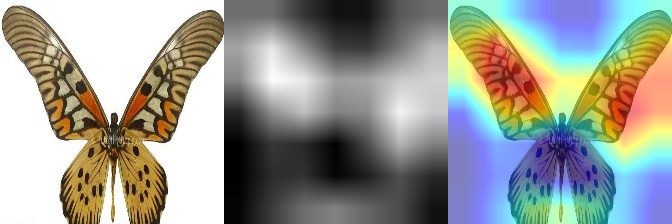

In [24]:
# Load the image using PIL and convert it into a NumPy array
img = np.array(Image.open("/content/valid/AFRICAN GIANT SWALLOWTAIL/2.jpg"))

# Resize the image to 224x224 pixels (this is the expected input size for many pre-trained models like ResNet)
img = cv2.resize(img, (224, 224))

# Normalize the pixel values to a range of [0, 1] by dividing by 255
img = np.float32(img) / 255  # Convert to float32 type to avoid integer division and ensure precision

# Apply image preprocessing transformations including normalization
input_tensor = preprocess_image(img, mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])


# Define the target for the classifier output
targets = [ClassifierOutputTarget(1)]
# 'ClassifierOutputTarget' is used to specify the target layer/output for classification.
# The '0' refers to the index of the class or output you're targeting.

# Define the layers from the model where you want to extract features
target_layers = [model.layer4]
# 'model.layer4' refers to the fourth block of layers in ResNet50.
# You may use this for feature extraction from this specific layer.



# Initialize the GradCAM object for the specified model and target layers
with GradCAM(model=model, target_layers=target_layers) as cam:
    # 'model' is your trained model (e.g., ResNet50).
    # 'target_layers' refers to the layers where GradCAM will be applied, in this case, 'model.layer4'.

    # Apply GradCAM to get the class activation map (CAM) for the input tensor
    grayscale_cams = cam(input_tensor=input_tensor, targets=targets)
    # 'input_tensor' is the preprocessed image tensor ready for the model.
    # 'targets' are the class labels you're targeting (e.g., the first class).
    # 'grayscale_cams' will be the generated CAMs for the specific class at the specified layer(s).

    # Generate and display the CAM on the original image
    cam_image = show_cam_on_image(img, grayscale_cams[0, :], use_rgb=True)
    # 'show_cam_on_image' overlays the generated CAM (grayscale_cams) onto the original image ('img').
    # 'use_rgb=True' ensures that the resulting CAM is in RGB format for proper visualization.

# Convert the grayscale CAM to an 8-bit image (range [0, 255])
cam = np.uint8(255 * grayscale_cams[0, :])
# 'grayscale_cams[0, :]' contains the CAM for the first target class.
# We multiply by 255 to scale the grayscale CAM values to the [0, 255] range,
# then convert to uint8 type (8-bit per channel) for proper image display.

# Convert the single channel CAM into a 3-channel image
cam = cv2.merge([cam, cam, cam])
# 'cv2.merge()' creates a 3-channel image (RGB) by duplicating the single grayscale channel.
# This makes it compatible with standard color image processing or visualization.

# Stack the original image, grayscale CAM, and overlaid CAM horizontally
images = np.hstack((np.uint8(255 * img), cam, cam_image))
# 'np.hstack()' horizontally stacks the images.
# - 'np.uint8(255 * img)' converts the original image to uint8 format.
# - 'cam' is the grayscale CAM in a 3-channel format.
# - 'cam_image' is the overlaid image, which already contains the CAM on the original image.

# Convert the stacked images array to an image and display it
Image.fromarray(images)
# 'Image.fromarray()' converts the NumPy array to a PIL Image object for display.


**Credits:**

I would like to acknowledge all the resources that I used for this tutorial

1. https://github.com/jacobgil/pytorch-grad-cam/blob/master/tutorials/CAM%20Metrics%20And%20Tuning%20Tutorial.ipynb
2. https://www.geeksforgeeks.org/python-pil-image-open-method/
3. https://www.geeksforgeeks.org/how-to-import-kaggle-datasets-directly-into-google-colab/
4. https://www.kaggle.com/code/almabady/butterfly-species-cnn-accuracy-0-84
5. https://debuggercafe.com/pytorch-imagefolder-for-training-cnn-models/


**Suggested Reading:**

For more hands-on experience, I would suggest these resources.

1. https://www.coursera.org/projects/deep-learning-with-pytorch-gradcam
2. https://jacobgil.github.io/pytorch-gradcam-book/introduction.html